In [56]:
import os
import re
import csv
import numpy as np
import pandas as pd
from ase.io import read
import matplotlib.pyplot as plt

# Show float values with 2 decimal places when displaying DataFrames.
pd.options.display.float_format = '{:.2f}'.format

# Ensure wide DataFrames print all columns (no truncation).
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 20000)
pd.set_option('display.expand_frame_repr', True)

root = '/Users/jiuy97/Desktop/3_RuO2/6_ICOHP'
# root = '/Users/hailey/Desktop/3_RuO2/6_ICOHP/4_slab_M-RuO2'
# oxygen_potential = -4.658724749999999 # 300K
# oxygen_potential = -4.658724749999999+0.27-0.73 # 700K
oxygen_potential = -4.658724749999999+0.27-0.85 # 800K
figsize = (4, 3)
dpi = 300

In [57]:
data = pd.DataFrame()
subdirs = ['0_Ru', '1_Hf', '2_Ta', '3_W', '4_Re', '5_Os', '6_Ir', '7_Pt']
elements = ['Ru', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt']

In [58]:
for dir in ['1_cus_V_V', '2_brg_V_V', '3_cus_O_O', '4_brg_O_O']:
    ads_site = dir.split('_')[1]
    coverage = dir.split('_')[2]
    for e, element in enumerate(elements):
        path = os.path.join(root, '4_slab_M-RuO2', dir, f'{e}_{element}', 'atoms_bader_charge.json')
        if os.path.exists(path):
            atoms = read(path)
            chgs = atoms.get_initial_charges()
            for i, chg in enumerate(chgs):
                data.loc[f'{ads_site}_{coverage}_{element}', i] = chg

data = data.drop(columns=[48, 49], errors='ignore')
data


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47
cus_V_Ru,1.62,1.62,1.73,1.73,1.72,1.72,1.71,1.71,1.72,1.72,1.63,1.63,1.76,1.76,1.68,1.68,-0.80,-0.80,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.87,-0.87,-0.87,-0.87,-0.86,-0.86,-0.84,-0.84,-0.87,-0.87,-0.87,-0.87,-0.77,-0.77
cus_V_Hf,1.61,1.60,1.72,1.72,1.71,1.71,1.72,1.72,1.72,1.72,1.63,1.63,1.74,1.74,1.63,2.38,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.80,-0.90,-0.87,-0.90,-0.97,-0.97,-0.97,-0.97,-0.82,-0.76
cus_V_Ta,1.61,1.61,1.73,1.73,1.71,1.71,1.71,1.72,1.72,1.72,1.61,1.61,1.73,1.73,1.46,2.64,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.86,-0.87,-0.83,-0.82,-0.87,-0.87,-0.87,-0.87,-0.79,-0.92,-0.87,-0.90,-0.98,-0.98,-0.98,-0.98,-0.79,-0.76
cus_V_W,1.61,1.60,1.72,1.72,1.71,1.71,1.72,1.71,1.72,1.72,1.60,1.60,1.69,1.69,1.45,2.62,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.88,-0.88,-0.88,-0.88,-0.87,-0.87,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.79,-0.90,-0.87,-0.89,-0.93,-0.93,-0.93,-0.93,-0.80,-0.82
cus_V_Re,1.61,1.61,1.72,1.72,1.71,1.71,1.72,1.71,1.72,1.73,1.61,1.61,1.70,1.70,1.48,2.32,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.81,-0.82,-0.87,-0.87,-0.87,-0.87,-0.80,-0.87,-0.88,-0.89,-0.90,-0.90,-0.90,-0.90,-0.78,-0.79
cus_V_Os,1.61,1.62,1.77,1.77,1.71,1.71,1.72,1.71,1.72,1.72,1.61,1.61,1.73,1.73,1.52,1.93,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.85,-0.85,-0.83,-0.83,-0.88,-0.88,-0.88,-0.88,-0.87,-0.87,-0.82,-0.82,-0.87,-0.87,-0.87,-0.87,-0.79,-0.80,-0.87,-0.87,-0.88,-0.88,-0.88,-0.88,-0.76,-0.76
cus_V_Ir,1.62,1.63,1.73,1.73,1.72,1.72,1.72,1.72,1.72,1.72,1.63,1.63,1.74,1.74,1.63,1.58,-0.80,-0.80,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.74,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.74,-0.73
cus_V_Pt,1.63,1.64,1.75,1.75,1.72,1.72,1.71,1.72,1.73,1.73,1.68,1.68,1.77,1.77,1.64,1.21,-0.78,-0.78,-0.86,-0.86,-0.86,-0.86,-0.84,-0.83,-0.84,-0.84,-0.88,-0.88,-0.88,-0.88,-0.87,-0.87,-0.82,-0.82,-0.87,-0.87,-0.87,-0.87,-0.81,-0.71,-0.87,-0.87,-0.85,-0.85,-0.85,-0.85,-0.74,-0.73
brg_V_Ru,1.62,1.62,1.73,1.73,1.72,1.72,1.71,1.71,1.72,1.72,1.63,1.63,1.76,1.76,1.68,1.68,-0.80,-0.80,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.87,-0.87,-0.87,-0.87,-0.86,-0.86,-0.84,-0.84,-0.87,-0.87,-0.87,-0.87,-0.77,-0.77
brg_V_Hf,1.62,1.62,1.72,1.73,1.72,1.72,1.71,1.71,1.73,1.73,1.63,1.63,1.91,1.62,1.62,2.26,-0.80,-0.80,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.87,-0.88,-0.87,-0.88,-0.81,-0.81,-0.91,-0.91,-0.88,-0.90,-0.88,-0.90,-0.98,-0.98


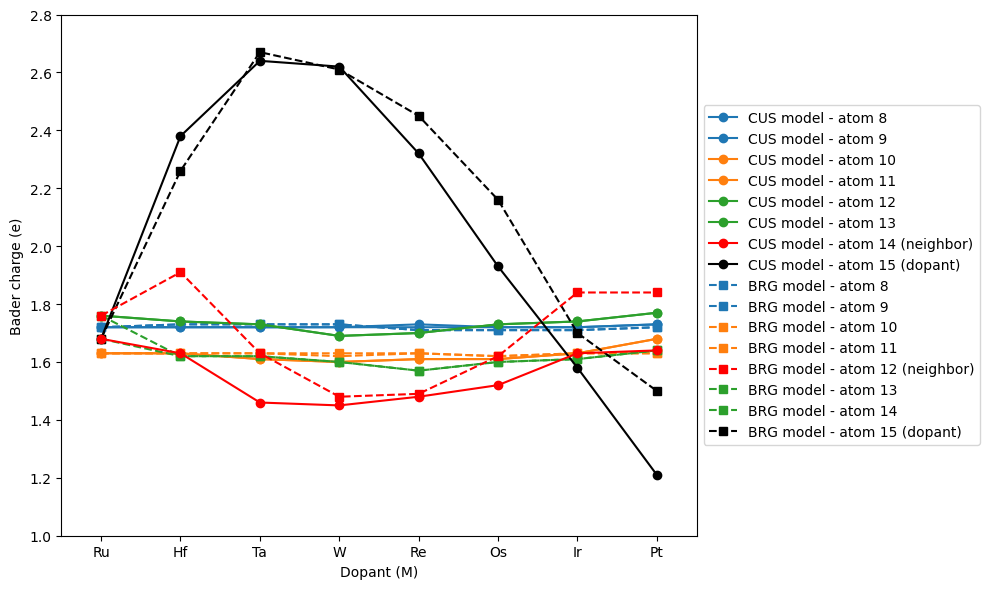

In [59]:
plt.figure(figsize=(10,6))

# colors = ['silver', 'silver', 'black', 'black', 'black', 'black', 'black', 'black',
colors1 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:green', 'tab:green', 'red', 'black']
colors2 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'red', 'tab:green', 'tab:green', 'black']

for i in range(8,16):
    zorder = i
    if i == 15:
        label = f'CUS model - atom {i} (dopant)'
    elif i == 14:
        label = f'CUS model - atom {i} (neighbor)'
        zorder = 16
    else:
        label = f'CUS model - atom {i}'
    plt.plot(
        elements, 
        data[i][0:8], 
        marker='o',
        label=label,
        color=colors1[i % len(colors1)],
        zorder=zorder
    )

for i in range(8,16):
    zorder = i
    if i == 15:
        label = f'BRG model - atom {i} (dopant)'
    elif i == 12:
        label = f'BRG model - atom {i} (neighbor)'
        zorder = 16
    else:
        label = f'BRG model - atom {i}'
    plt.plot(
        elements, 
        data[i][8:16], 
        linestyle='--',
        marker='s',
        label=label,
        color=colors2[i % len(colors2)],
        zorder=zorder
    )
    
plt.xlabel('Dopant (M)')
plt.ylabel('Bader charge (e)')
plt.ylim(1.0, 2.8)

plt.xlim(-0.5, 7.5)
plt.xticks(range(len(elements)), elements)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
# plt.savefig(f'{root}/figures/surface_site_preference.png', dpi=dpi, transparent=True, bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
for dir in ['1_bulk_MO2', '2_bulk_MxOy']:
    oxide_type = dir.split('_')[2]
    for e, element in enumerate(elements):
        path = os.path.join(root, dir, f'{e}_{element}', 'atoms_bader_charge.json')
        if os.path.exists(path):
            atoms = read(path)
            chgs = atoms.get_initial_charges()
            metal_chgs = [chg for atom, chg in zip(atoms, chgs) if atom.symbol != 'O']
            chg_metal = sum(metal_chgs) / len(metal_chgs)
            for ads_site in ['cus', 'brg']:
                for coverage in ['V', 'O']:
                    data.loc[f'{ads_site}_{coverage}_{element}', oxide_type] = chg_metal

for dir in ['3_bulk_M-RuO2']:
    oxide_type = dir.split('_')[2]
    for subdir in subdirs:
        element = subdir.split('_')[1]
        path = os.path.join(root, dir, f'{e}_{element}', 'atoms_bader_charge.json')
        if os.path.exists(path):
            atoms = read(path)
            chgs = atoms.get_initial_charges()
            if element == 'Ru':
                M_index = [i for i, atom in enumerate(atoms) if atom.symbol == 'Ru']
                Ru_index = [i for i, atom in enumerate(atoms) if atom.symbol == 'Ru']
            else:
                M_index = [i for i, atom in enumerate(atoms) if atom.symbol != 'O' and atom.symbol != 'Ru']
                Ru_index = [i for i, atom in enumerate(atoms) if atom.symbol == 'Ru' and i != 4]
            print(M_index, Ru_index)
            M_chg = sum(chgs[M_index])/len(M_index)
            Ru_chg = sum(chgs[Ru_index])/len(Ru_index)
            for ads_site in ['cus', 'brg']:
                for coverage in ['V', 'O']:
                    data.loc[f'{ads_site}_{coverage}_{element}', f'{oxide_type}(M)'] = M_chg
                    data.loc[f'{ads_site}_{coverage}_{element}', f'{oxide_type}(Ru)'] = Ru_chg

data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,MO2,MxOy,M-RuO2(M),M-RuO2(Ru)
cus_V_Ru,1.62,1.62,1.73,1.73,1.72,1.72,1.71,1.71,1.72,1.72,1.63,1.63,1.76,1.76,1.68,1.68,-0.80,-0.80,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.87,-0.87,-0.87,-0.87,-0.86,-0.86,-0.84,-0.84,-0.87,-0.87,-0.87,-0.87,-0.77,-0.77,1.74,1.74,NaN,NaN
cus_V_Hf,1.61,1.60,1.72,1.72,1.71,1.71,1.72,1.72,1.72,1.72,1.63,1.63,1.74,1.74,1.63,2.38,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.80,-0.90,-0.87,-0.90,-0.97,-0.97,-0.97,-0.97,-0.82,-0.76,2.38,2.35,NaN,NaN
cus_V_Ta,1.61,1.61,1.73,1.73,1.71,1.71,1.71,1.72,1.72,1.72,1.61,1.61,1.73,1.73,1.46,2.64,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.86,-0.87,-0.83,-0.82,-0.87,-0.87,-0.87,-0.87,-0.79,-0.92,-0.87,-0.90,-0.98,-0.98,-0.98,-0.98,-0.79,-0.76,2.15,2.64,NaN,NaN
cus_V_W,1.61,1.60,1.72,1.72,1.71,1.71,1.72,1.71,1.72,1.72,1.60,1.60,1.69,1.69,1.45,2.62,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.88,-0.88,-0.88,-0.88,-0.87,-0.87,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.79,-0.90,-0.87,-0.89,-0.93,-0.93,-0.93,-0.93,-0.80,-0.82,2.11,2.66,NaN,NaN
cus_V_Re,1.61,1.61,1.72,1.72,1.71,1.71,1.72,1.71,1.72,1.73,1.61,1.61,1.70,1.70,1.48,2.32,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.81,-0.82,-0.87,-0.87,-0.87,-0.87,-0.80,-0.87,-0.88,-0.89,-0.90,-0.90,-0.90,-0.90,-0.78,-0.79,2.04,2.43,NaN,NaN
cus_V_Os,1.61,1.62,1.77,1.77,1.71,1.71,1.72,1.71,1.72,1.72,1.61,1.61,1.73,1.73,1.52,1.93,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.85,-0.85,-0.83,-0.83,-0.88,-0.88,-0.88,-0.88,-0.87,-0.87,-0.82,-0.82,-0.87,-0.87,-0.87,-0.87,-0.79,-0.80,-0.87,-0.87,-0.88,-0.88,-0.88,-0.88,-0.76,-0.76,1.81,1.81,NaN,NaN
cus_V_Ir,1.62,1.63,1.73,1.73,1.72,1.72,1.72,1.72,1.72,1.72,1.63,1.63,1.74,1.74,1.63,1.58,-0.80,-0.80,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.74,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.74,-0.73,1.70,1.63,NaN,NaN
cus_V_Pt,1.63,1.64,1.75,1.75,1.72,1.72,1.71,1.72,1.73,1.73,1.68,1.68,1.77,1.77,1.64,1.21,-0.78,-0.78,-0.86,-0.86,-0.86,-0.86,-0.84,-0.83,-0.84,-0.84,-0.88,-0.88,-0.88,-0.88,-0.87,-0.87,-0.82,-0.82,-0.87,-0.87,-0.87,-0.87,-0.81,-0.71,-0.87,-0.87,-0.85,-0.85,-0.85,-0.85,-0.74,-0.73,1.56,1.49,1.54,1.73
brg_V_Ru,1.62,1.62,1.73,1.73,1.72,1.72,1.71,1.71,1.72,1.72,1.63,1.63,1.76,1.76,1.68,1.68,-0.80,-0.80,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.87,-0.87,-0.87,-0.87,-0.86,-0.86,-0.84,-0.84,-0.87,-0.87,-0.87,-0.87,-0.77,-0.77,1.74,1.74,NaN,NaN
brg_V_Hf,1.62,1.62,1.72,1.73,1.72,1.72,1.71,1.71,1.73,1.73,1.63,1.63,1.91,1.62,1.62,2.26,-0.80,-0.80,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.87,-0.88,-0.87,-0.88,-0.81,-0.81,-0.91,-0.91,-0.88,-0.90,-0.88,-0.90,-0.98,-0.98,2.38,2.35,NaN,NaN
